In [23]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.utils import resample
from agents.ffnn_agent2 import FFNNAgent
from torch.utils.data import TensorDataset, DataLoader
import torch
import matplotlib.pyplot as pltimage
import random
import os
import json
from itertools import cycle
from typing import List, Dict

In [24]:
import re
from pathlib import Path

# ---------- Helpers ----------

def is_seed_dir(p: Path) -> bool:
    return (
        p.is_dir()
        and p.name.startswith("seed_")
        and (p / "metrics.csv").is_file()
        and (p / "meta.json").is_file()
    )

def is_experiment_dir(p: Path) -> bool:
    if not p.is_dir():
        return False
    return any(is_seed_dir(d) for d in p.iterdir())

# Regex to extract PCA, minID, majID, BIAS
CORE_RE = re.compile(
    r"PCA(?P<pca>\d+).*?minID(?P<min>\d+).*?majID(?P<maj>\d+).*?BIAS(?P<bias>[0-9.]+)",
    re.IGNORECASE,
)

def make_short_label(exp_name: str) -> str:
    """
    Extract PCA, minID, majID, bias from a folder name.
    Return a short readable label like:
        PCA4_min1_maj0_bias0.35
    """
    m = CORE_RE.search(exp_name)
    if not m:
        # fallback: return the core part without DATE
        core = exp_name.split("_DATE")[0]
        return core

    pca = m.group("pca")
    min_id = m.group("min")
    maj_id = m.group("maj")
    bias = m.group("bias")

    return f"PCA{pca}_min{min_id}_maj{maj_id}_bias{bias}"

# ---------- Main Generator ----------

def generate_experiment_labels_dict():
    training_root = Path("training_runs")
    if not training_root.is_dir():
        print("[error] training_runs/ does not exist.")
        return

    exp_dirs = sorted(
        [d for d in training_root.iterdir() if is_experiment_dir(d)],
        key=lambda p: p.name,
    )

    if not exp_dirs:
        print("[info] No experiment folders found.")
        return

    print("\n# ================= GENERATED EXPERIMENT_LABELS =================")
    print("EXPERIMENT_LABELS = {")
    for d in exp_dirs:
        short = make_short_label(d.name)
        print(f'    "{d.name}": "{short}",')
    print("}")
    print("# ==============================================================\n")

# Run immediately
generate_experiment_labels_dict()



# ================= GENERATED EXPERIMENT_LABELS =================
EXPERIMENT_LABELS = {
    "BASELINE_group_dro_baseline_gdro_census_663e8736__G202603121735": "BASELINE_group_dro_baseline_gdro_census_663e8736__G202603121735",
    "BASELINE_group_dro_baseline_gdro_census_738fc989__G202603111900": "BASELINE_group_dro_baseline_gdro_census_738fc989__G202603111900",
    "BASELINE_group_dro_baseline_gdro_census_seed42_12dcccbd__G202603161757": "BASELINE_group_dro_baseline_gdro_census_seed42_12dcccbd__G202603161757",
    "BASELINE_group_dro_baseline_gdro_census_seed42_7d9629d9__G202603161801": "BASELINE_group_dro_baseline_gdro_census_seed42_7d9629d9__G202603161801",
    "BASELINE_group_dro_baseline_gdro_census_seed42_f91845b3__G202603161746": "BASELINE_group_dro_baseline_gdro_census_seed42_f91845b3__G202603161746",
    "BASELINE_group_dro_baseline_gdro_credit_0f79e8fe__G202603121736": "BASELINE_group_dro_baseline_gdro_credit_0f79e8fe__G202603121736",
    "BASELINE_group_dro_baseline_gdro_cre

[info] Using 6 experiment folders from EXPERIMENT_LABELS.
[info] Discovered 3 numeric time-series metrics to plot.


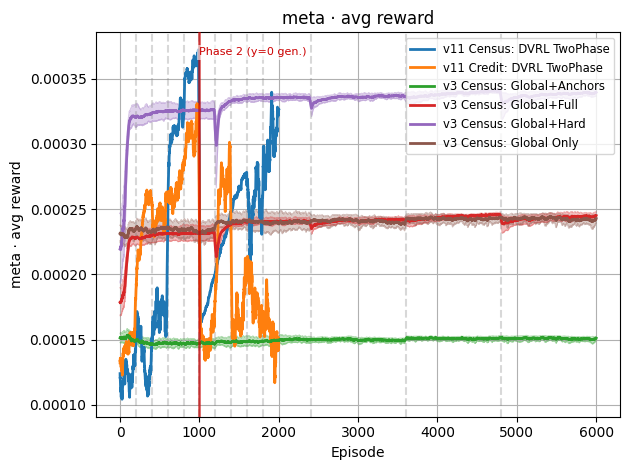

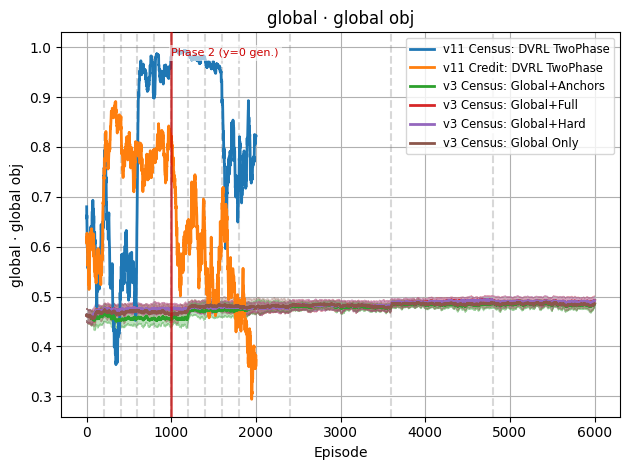

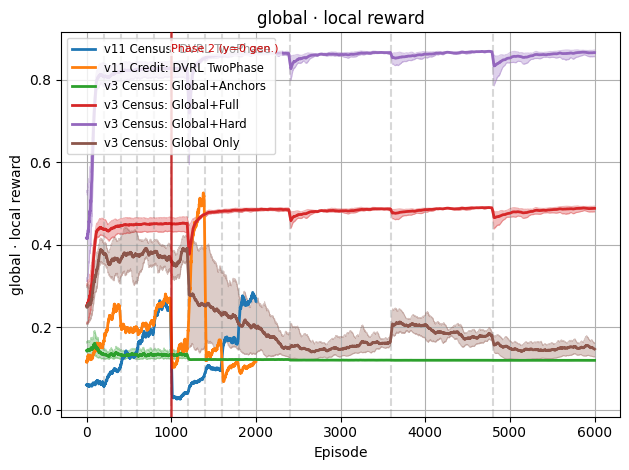

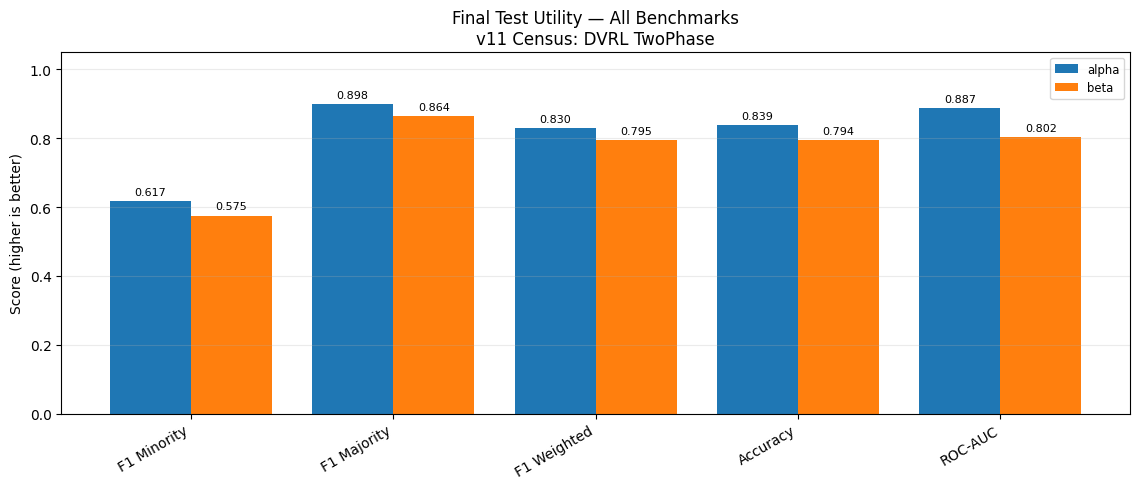

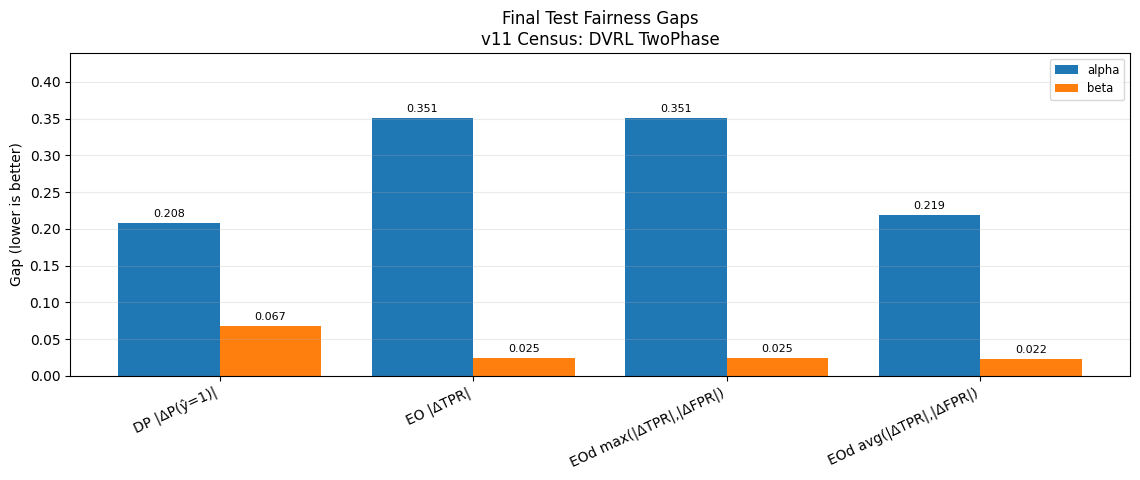

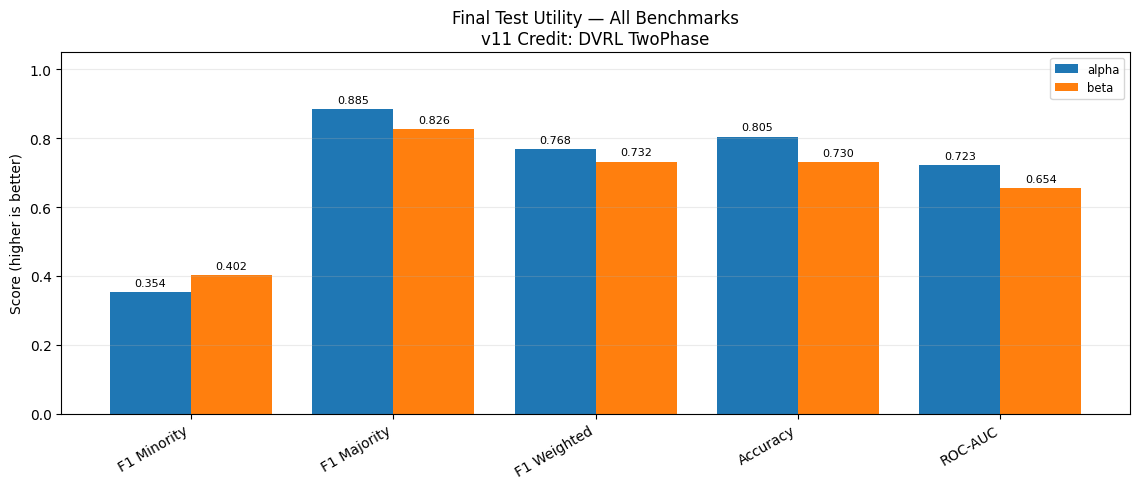

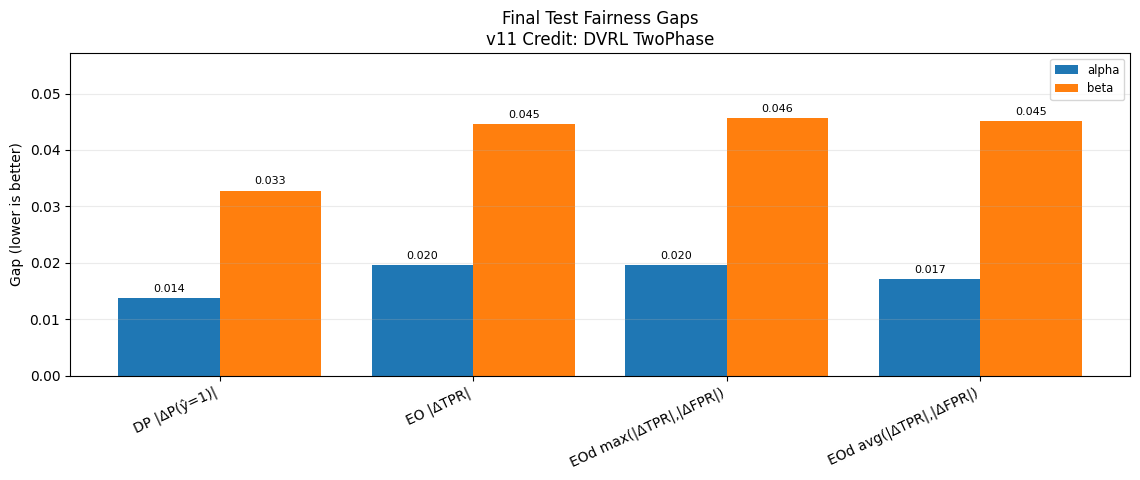

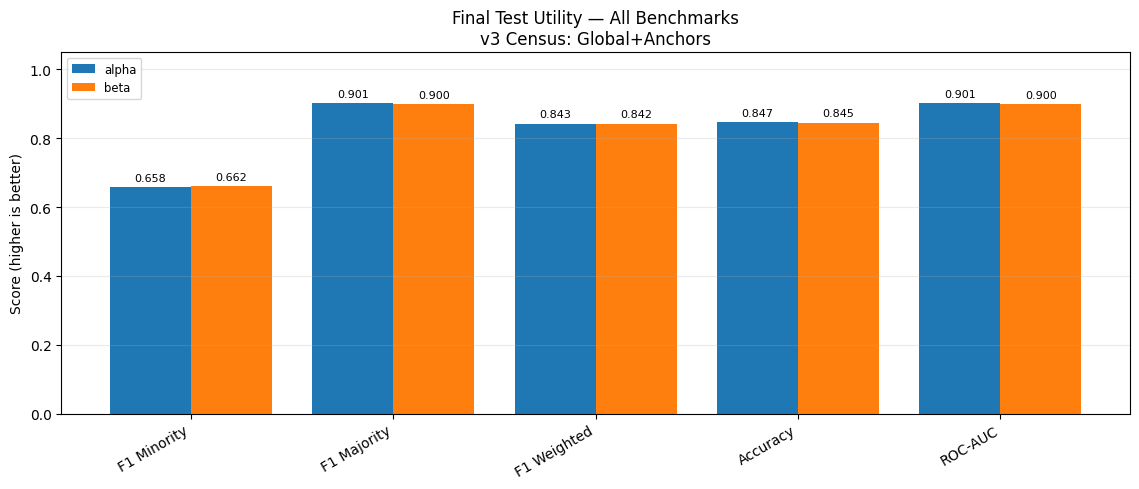

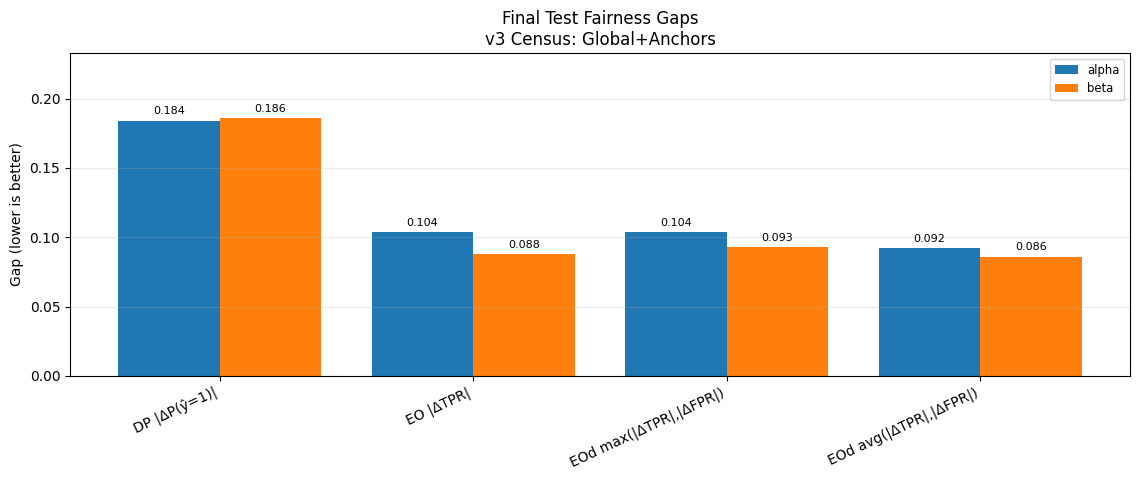

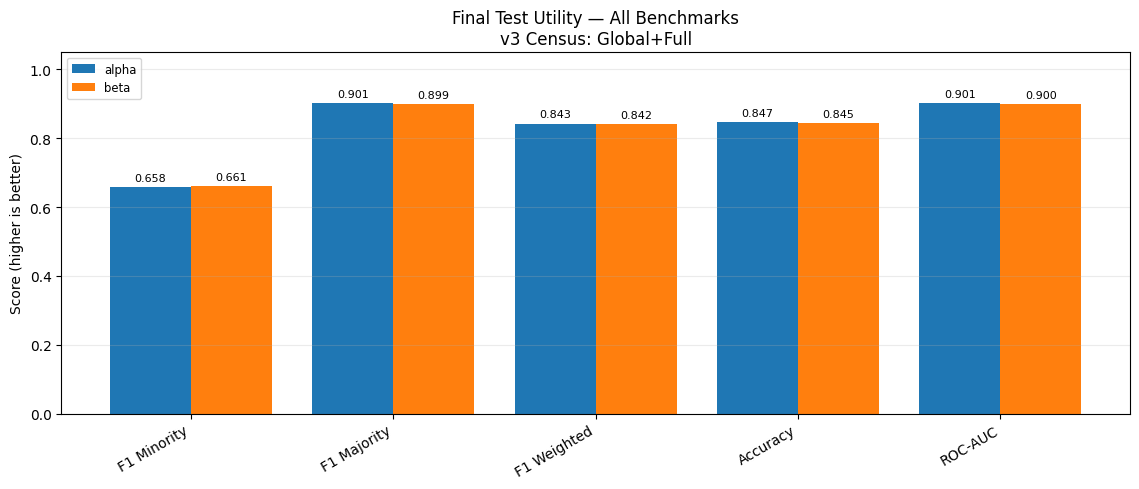

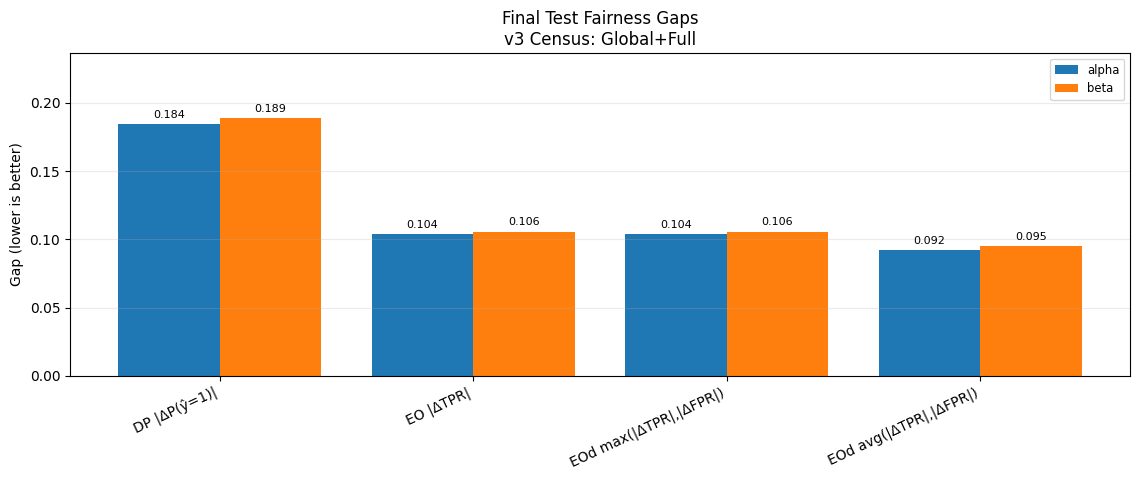

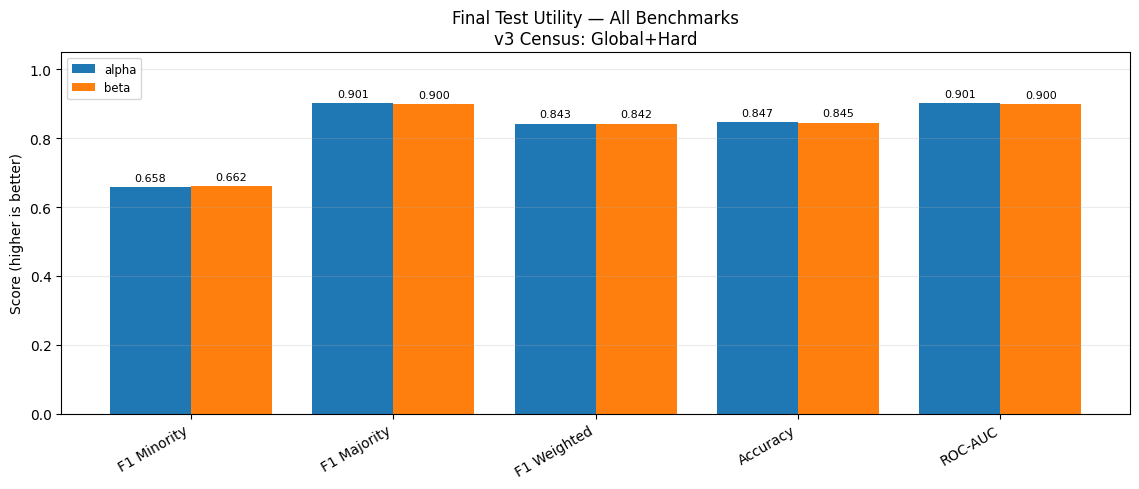

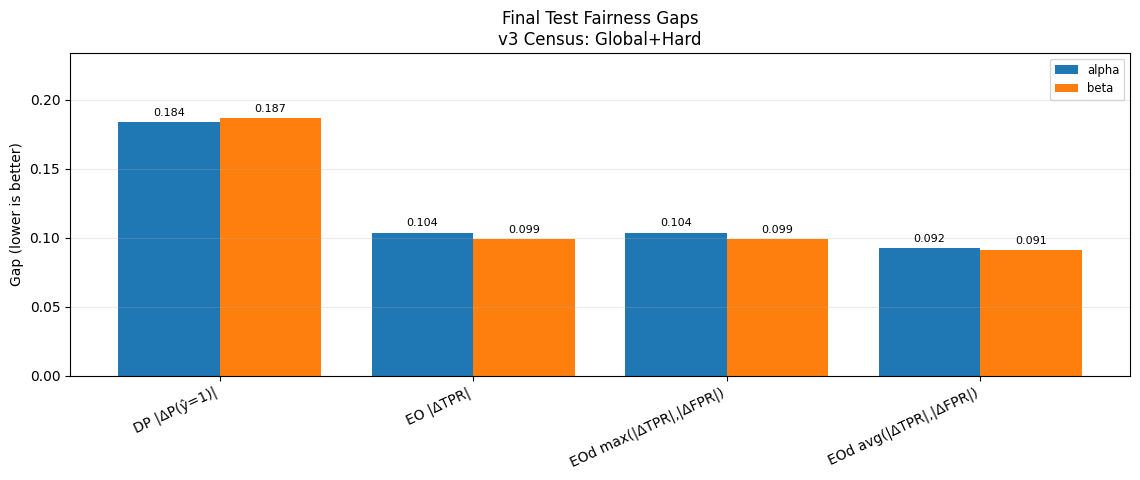

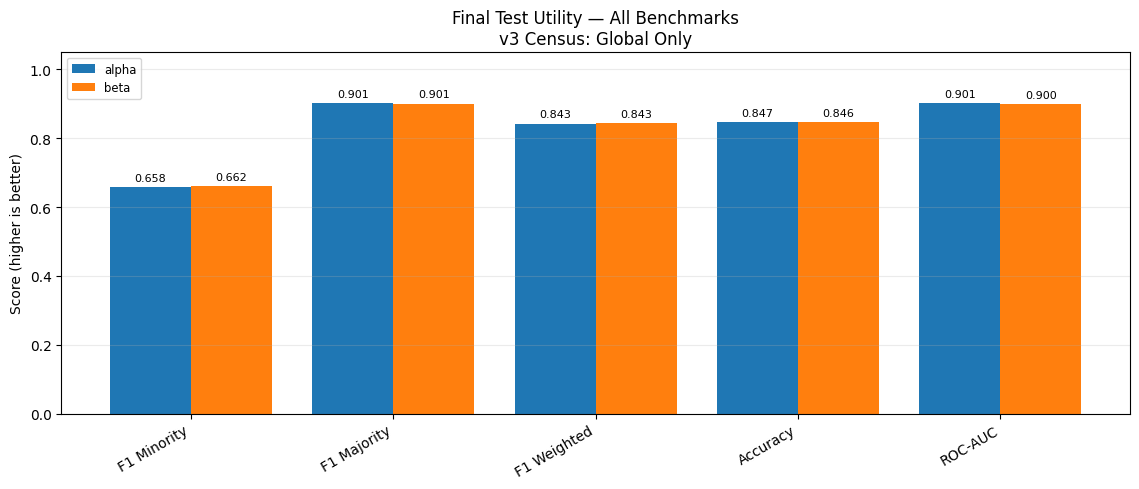

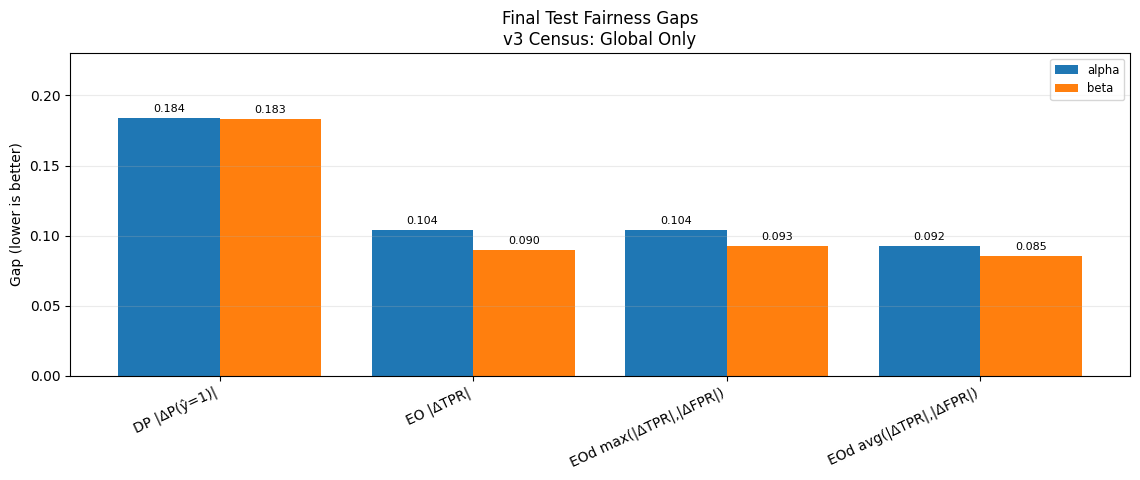

In [25]:
"""
Drop-in plotting script for training_runs/

What it does:
1) Auto-discovers ALL numeric time-series metrics in seed_*/metrics.csv and plots them.
   - Easy toggles at top to include/exclude prefixes or specific columns.
2) For each experiment, creates TWO final bar plots from final_test_metrics.csv:
   - Utility (F1s + Accuracy + ROC-AUC): Alpha vs Beta vs (optional) CTGAN/CTAB/etc if present
   - Fairness gaps (DP / EO / EOd): Alpha vs Beta (and optional baselines if present)

Run from project root:
  python plot_metrics.py
"""

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("training_runs")

# ============================================================
# 0) QUICK TOGGLES (comment out what you don't want)
# ============================================================
PLOT_TIME_SERIES = True
PLOT_FINAL_BARS_UTILITY = True
PLOT_FINAL_BARS_FAIRNESS = True
SHOW_CURRICULUM_LINES = True

SMOOTH_WINDOW = 25  # set to 1 or None to disable smoothing

# --- easiest way to control which time-series get plotted ---
# Option A (recommended): choose prefixes (everything starting with these)
TIME_SERIES_INCLUDE_PREFIXES = [
    "meta", "global", "utility", "fairness", "local", "extra", "align"
]
# Example:
# TIME_SERIES_INCLUDE_PREFIXES = ["meta", "global", "utility"]

# Option B: additionally blacklist specific columns (even if prefix is included)
TIME_SERIES_EXCLUDE_COLS = {
    "wall_seconds",
    "align.reward_mode",  # usually string
}

# If you prefer plotting ONLY a few specific columns, set this to a non-empty list:
# (when non-empty, it overrides prefix logic)
TIME_SERIES_ONLY_COLS = [
    "meta.avg_reward",
    "global.global_obj",
    "global.local_reward",
]

# Column name for curriculum stage (vertical lines)
STAGE_COL = "align.curriculum_stage"


EXPERIMENT_LABELS = {

    # ── v3 Census (6000 eps, single-phase) ──────────────────────────────────
    "SPECv3_census_ablation_global_anchors_EP6000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202603092248_97f273d4": "v3 Census: Global+Anchors",
    "SPECv3_census_ablation_global_full_EP6000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202603092248_2f9e695b": "v3 Census: Global+Full",
    "SPECv3_census_ablation_global_hard_EP6000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202603092248_64d2ac98": "v3 Census: Global+Hard",
    "SPECv3_census_ablation_global_only_EP6000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202603092248_a14e2643": "v3 Census: Global Only",

    # ── v11 Two-Phase DVRL (1000 eps / phase) ───────────────────────────────
    "SPECv11_census_dvrl_twophase_1000_EP1000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202603161455_5919adff": "v11 Census: DVRL TwoPhase",
    "SPECv11_credit_dvrl_twophase_1000_EP1000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202603161455_00f93975": "v11 Credit: DVRL TwoPhase",
#     "SPECv3_credit_ablation_global_anchors_EP6000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202603071844_7fee08dc": "SPECv3_credit_ablation_global_anchors_EP6000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202603071844_7fee08dc",
#     "SPECv3_credit_ablation_global_full_EP6000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202603071927_0f291fd9": "SPECv3_credit_ablation_global_full_EP6000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202603071927_0f291fd9",
#     "SPECv3_credit_ablation_global_hard_EP6000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202603071924_a805a833": "SPECv3_credit_ablation_global_hard_EP6000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202603071924_a805a833",
#     "SPECv3_credit_ablation_global_only_EP6000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202603071958_80b395b6": "SPECv3_credit_ablation_global_only_EP6000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202603071958_80b395b6",
#     "SPECv3_credit_budget_high_ratio_EP6000_PCA10_REWfairness_minID1_majID0_TRJ6000_REAL3000_GG202603071838_8d4e5a4a": "SPECv3_credit_budget_high_ratio_EP6000_PCA10_REWfairness_minID1_majID0_TRJ6000_REAL3000_GG202603071838_8d4e5a4a",
#     "SPECv3_credit_budget_more_synth_EP6000_PCA10_REWfairness_minID1_majID0_TRJ4000_REAL3000_GG202603071841_5661416d": "SPECv3_credit_budget_more_synth_EP6000_PCA10_REWfairness_minID1_majID0_TRJ4000_REAL3000_GG202603071841_5661416d",
#     "SPECv3_credit_budget_scale_up_EP6000_PCA10_REWfairness_minID1_majID0_TRJ4000_REAL6000_GG202603071838_7453c23a": "SPECv3_credit_budget_scale_up_EP6000_PCA10_REWfairness_minID1_majID0_TRJ4000_REAL6000_GG202603071838_7453c23a",
#     "SPECv3_credit_budget_scale_up_large_EP6000_PCA10_REWfairness_minID1_majID0_TRJ6000_REAL9000_GG202603072007_c8eb463d": "SPECv3_credit_budget_scale_up_large_EP6000_PCA10_REWfairness_minID1_majID0_TRJ6000_REAL9000_GG202603072007_c8eb463d",
#     "SPECv3_credit_budget_very_high_ratio_EP6000_PCA10_REWfairness_minID1_majID0_TRJ9000_REAL3000_GG202603072007_ac3cf5b3": "SPECv3_credit_budget_very_high_ratio_EP6000_PCA10_REWfairness_minID1_majID0_TRJ9000_REAL3000_GG202603072007_ac3cf5b3",
 }

# Paired baselines: BASELINE_LABELS[i] is plotted alongside EXPERIMENT_LABELS[i]
# in the same final bar chart (baseline beta shown as an extra bar group).
BASELINE_LABELS = {
#     "BASELINE_folder_name": "Baseline Label",
}
# ---------------------------------------------------------------------
# Helpers to identify experiment + seed folders
# ---------------------------------------------------------------------
def is_seed_dir(p: Path) -> bool:
    return (
        p.is_dir()
        and p.name.startswith("seed_")
        and (p / "metrics.csv").is_file()
        and (p / "meta.json").is_file()
    )

def is_experiment_dir(p: Path) -> bool:
    if not p.is_dir():
        return False
    seeds = [d for d in p.iterdir() if is_seed_dir(d)]
    return len(seeds) > 0

# ---------------------------------------------------------------------
# Parse experiment name (for auto labels if needed)
# ---------------------------------------------------------------------
CORE_RE = re.compile(
    r"^EP(?P<episodes>\d+)_"
    r"PCA(?P<pca>\d+)_"
    r"REW(?P<rew>.+?)_"
    r"minID(?P<min>\d+)_"
    r"majID(?P<maj>\d+)_"
    r"TRJ(?P<trj>\d+)_"
    r"REAL(?P<real>\d+)_"
    r"BIAS(?P<bias>[0-9.]+)"
)

def split_core_and_tail(name: str):
    if "_DATE" in name:
        core, tail = name.split("_DATE", 1)
        return core, tail
    return name, ""

def parse_experiment_name(name: str):
    core, _ = split_core_and_tail(name)
    m = CORE_RE.match(core)
    if not m:
        return {"core": core}
    d = m.groupdict()
    d["core"] = core
    for k in ("episodes", "pca", "min", "maj", "trj", "real"):
        d[k] = int(d[k])
    d["bias"] = float(d["bias"])
    return d

def make_auto_label(info: dict) -> str:
    if not info:
        return "unknown"
    return (
        f"PCA{info.get('pca', '?')}_"
        f"min{info.get('min', '?')}_"
        f"maj{info.get('maj', '?')}_"
        f"bias{info.get('bias', '?')}"
    )

def label_for_folder(folder_name: str, info: dict) -> str:
    if folder_name in EXPERIMENT_LABELS:
        return EXPERIMENT_LABELS[folder_name]
    return make_auto_label(info)

# ---------------------------------------------------------------------
# Training metrics (metrics.csv)
# ---------------------------------------------------------------------
def load_seed_metrics(seed_dir: Path) -> pd.DataFrame | None:
    try:
        df = pd.read_csv(seed_dir / "metrics.csv")
    except Exception as e:
        print(f"[warn] Could not read {seed_dir / 'metrics.csv'}: {e}")
        return None

    if "episode" not in df.columns:
        print(f"[warn] No 'episode' column in {seed_dir / 'metrics.csv'}, skipping this seed.")
        return None

    return df.copy()

def load_experiment_metrics_all_seeds(exp_dir: Path) -> pd.DataFrame | None:
    seed_dirs = [d for d in exp_dir.iterdir() if is_seed_dir(d)]
    if not seed_dirs:
        print(f"[info] No seeds found in {exp_dir}, skipping training curves.")
        return None

    dfs = []
    for sd in seed_dirs:
        df = load_seed_metrics(sd)
        if df is not None and not df.empty:
            df["seed"] = sd.name
            dfs.append(df)

    if not dfs:
        print(f"[info] All seeds in {exp_dir} unreadable/empty, skipping training curves.")
        return None

    all_df = pd.concat(dfs, ignore_index=True)
    all_df = all_df.sort_values(["episode", "seed"]).reset_index(drop=True)

    # Two-phase mode: make episode numbers continuous across phases.
    # Phase 1 episodes are [1..N]; Phase 2 resets to [1..N] — offset phase 2 by N.
    if "meta.phase" in all_df.columns:
        phase_vals = all_df["meta.phase"].fillna("")
        p1_mask = phase_vals.str.contains("phase1", na=False)
        p2_mask = phase_vals.str.contains("phase2", na=False)
        if p1_mask.any() and p2_mask.any():
            p1_max = all_df.loc[p1_mask, "episode"].max()
            all_df.loc[p2_mask, "episode"] = all_df.loc[p2_mask, "episode"] + p1_max
            all_df.attrs["phase2_start_ep"] = int(p1_max) + 1

    return all_df

# ---------------------------------------------------------------------
# Final test metrics (final_test_metrics.csv)
# ---------------------------------------------------------------------
def aggregate_final_metrics_for_experiment(exp_dir: Path) -> pd.Series | None:
    path = exp_dir / "final_test_metrics.csv"
    if not path.is_file():
        print(f"[info] No final_test_metrics.csv found in {exp_dir.name}, skipping final bars.")
        return None

    try:
        df = pd.read_csv(path)
    except Exception as e:
        print(f"[warn] Could not read {path}: {e}")
        return None

    if df.empty:
        print(f"[info] final_test_metrics.csv is empty for {exp_dir.name}.")
        return None

    return df.mean(numeric_only=True)

def smooth_agg_df(agg: pd.DataFrame, window: int | None) -> pd.DataFrame:
    if window is None or window <= 1:
        return agg
    agg = agg.sort_values("episode").reset_index(drop=True)
    for col in ("mean", "min", "max"):
        if col in agg.columns:
            agg[col] = agg[col].rolling(window=window, center=True, min_periods=1).mean()
    return agg

# ============================================================
# Time-series discovery + labeling
# ============================================================
def _prefix_of(col: str) -> str:
    return col.split(".", 1)[0] if "." in col else col

def discover_time_series_metrics(seed_cache: dict[str, pd.DataFrame]) -> list[str]:
    """
    Union all numeric metric columns across all experiments (excluding episode/seed/stage),
    then filter using TIME_SERIES_ONLY_COLS or prefix include/exclude lists.
    """
    all_cols = set()
    for _exp, df in seed_cache.items():
        for c in df.columns:
            if c in ("episode", "seed", STAGE_COL):
                continue
            if c in TIME_SERIES_EXCLUDE_COLS:
                continue
            if pd.api.types.is_numeric_dtype(df[c]):
                all_cols.add(c)

    # override: explicit list
    if TIME_SERIES_ONLY_COLS:
        wanted = []
        for c in TIME_SERIES_ONLY_COLS:
            if c in all_cols:
                wanted.append(c)
            else:
                print(f"[warn] TIME_SERIES_ONLY_COLS requested '{c}' but it wasn't found as numeric anywhere.")
        return wanted

    cols = sorted(all_cols)

    if TIME_SERIES_INCLUDE_PREFIXES:
        inc = set(TIME_SERIES_INCLUDE_PREFIXES)
        cols = [c for c in cols if _prefix_of(c) in inc]

    cols = sorted(cols, key=lambda c: (_prefix_of(c), c))
    return cols

def pretty_metric_label(col: str) -> str:
    return col.replace(".", " · ").replace("_", " ")

# ============================================================
# FINAL BAR PLOTS
# ============================================================
def _annotate(ax_, rects):
    for r in rects:
        h = r.get_height()
        if np.isfinite(h):
            ax_.annotate(
                f"{h:.3f}",
                xy=(r.get_x() + r.get_width() / 2, h),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=8
            )

def _discover_prefixes_for_utility(mean_series: pd.Series) -> list[str]:
    """
    Finds prefixes that have the standard utility suffixes in final_test_metrics.csv:
      <prefix>_f1_minority, _f1_majority, _f1_weighted, _acc, _roc_auc
    e.g. alpha, beta, alphaCT, alphaCTAB, oversample, undersample, jitter, ...
    """
    prefixes = set()
    for col in mean_series.index:
        if not isinstance(col, str):
            continue
        m = re.match(r"^(?P<prefix>.+?)_(f1_minority|f1_majority|f1_weighted|acc|roc_auc)$", col)
        if m:
            prefixes.add(m.group("prefix"))

    preferred = ["alpha", "beta", "alphaCT", "alphaCTAB", "oversample", "undersample", "jitter"]
    ordered = [p for p in preferred if p in prefixes] + sorted([p for p in prefixes if p not in preferred])
    return ordered

def plot_final_utility_bars(exp_label: str, mean_series: pd.Series):
    categories = [
        ("f1_minority", "F1 Minority"),
        ("f1_majority", "F1 Majority"),
        ("f1_weighted", "F1 Weighted"),
        ("acc",         "Accuracy"),
        ("roc_auc",     "ROC-AUC"),
    ]

    prefixes = _discover_prefixes_for_utility(mean_series)
    if not prefixes:
        print(f"[info] No utility prefix metrics found for {exp_label}. Skipping utility bars.")
        return None

    vals = []
    for p in prefixes:
        row = []
        for suf, _lbl in categories:
            key = f"{p}_{suf}"
            v = mean_series.get(key, np.nan)
            row.append(float(v) if v is not None else np.nan)
        vals.append(row)
    vals = np.array(vals, dtype=float)

    if np.all(np.isnan(vals)):
        print(f"[info] Utility bars all-NaN for {exp_label}. Skipping.")
        return None

    x = np.arange(len(categories))
    n = len(prefixes)
    group_width = 0.80
    bar_w = group_width / max(n, 1)
    offsets = (np.arange(n) - (n - 1) / 2.0) * bar_w

    fig, ax = plt.subplots(figsize=(11.5, 5))
    for i, p in enumerate(prefixes):
        bars = ax.bar(x + offsets[i], vals[i], bar_w, label=p)
        _annotate(ax, bars)

    ax.set_ylabel("Score (higher is better)")
    ax.set_title(f"Final Test Utility — All Benchmarks\n{exp_label}")
    ax.set_xticks(x)
    ax.set_xticklabels([lbl for _s, lbl in categories], rotation=30, ha="right")
    ax.set_ylim(0.0, 1.05)
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(fontsize="small")
    fig.tight_layout()
    return fig

def _discover_prefixes_for_fairness(mean_series: pd.Series) -> list[str]:
    """
    Finds prefixes that have fairness columns in final_test_metrics.csv.
    Required at least dp_diff or eo_tpr_diff (we'll plot what exists).
    Typically alpha_*, beta_*.
    """
    prefixes = set()
    for col in mean_series.index:
        if not isinstance(col, str) or "_" not in col:
            continue
        # match alpha_dp_diff, beta_eod_avg_diff, etc.
        m = re.match(r"^(?P<prefix>.+?)_(dp_diff|eo_tpr_diff|eod_max_diff|eod_avg_diff)$", col)
        if m:
            prefixes.add(m.group("prefix"))

    preferred = ["alpha", "beta", "alphaCT", "alphaCTAB", "oversample", "undersample", "jitter"]
    ordered = [p for p in preferred if p in prefixes] + sorted([p for p in prefixes if p not in preferred])
    return ordered

def plot_final_fairness_bars(exp_label: str, mean_series: pd.Series):
    fairness_metrics = [
        ("dp_diff",      "DP |ΔP(ŷ=1)|"),
        ("eo_tpr_diff",  "EO |ΔTPR|"),
        ("eod_max_diff", "EOd max(|ΔTPR|,|ΔFPR|)"),
        ("eod_avg_diff", "EOd avg(|ΔTPR|,|ΔFPR|)"),
    ]

    prefixes = _discover_prefixes_for_fairness(mean_series)
    if not prefixes:
        print(f"[info] No fairness columns found for {exp_label}. Skipping fairness bars.")
        return None

    # Build values: rows=prefixes, cols=fairness_metrics
    vals = []
    for p in prefixes:
        row = []
        for suf, _lbl in fairness_metrics:
            row.append(float(mean_series.get(f"{p}_{suf}", np.nan)))
        vals.append(row)
    vals = np.array(vals, dtype=float)

    if np.all(np.isnan(vals)):
        print(f"[info] Fairness bars all-NaN for {exp_label}. Skipping.")
        return None

    x = np.arange(len(fairness_metrics))
    n = len(prefixes)
    group_width = 0.80
    bar_w = group_width / max(n, 1)
    offsets = (np.arange(n) - (n - 1) / 2.0) * bar_w

    fig, ax = plt.subplots(figsize=(11.5, 4.9))
    for i, p in enumerate(prefixes):
        bars = ax.bar(x + offsets[i], vals[i], bar_w, label=p)
        _annotate(ax, bars)

    # scale y so tiny gaps are visible
    finite = vals[np.isfinite(vals)]
    ymax = 0.1 if finite.size == 0 else float(max(0.05, np.max(finite) * 1.25))

    ax.set_ylim(0.0, ymax)
    ax.set_ylabel("Gap (lower is better)")
    ax.set_title(f"Final Test Fairness Gaps\n{exp_label}")
    ax.set_xticks(x)
    ax.set_xticklabels([lbl for _s, lbl in fairness_metrics], rotation=25, ha="right")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(fontsize="small")
    fig.tight_layout()
    return fig

# ---------------------------------------------------------------------
# Main plotting logic
# ---------------------------------------------------------------------
def main():
    if not ROOT.is_dir():
        print(f"[error] {ROOT} does not exist. Run this from the project root.")
        return

    # --- Decide which experiment folders to use ---
    if EXPERIMENT_LABELS:
        exp_dirs = []
        for folder_name in EXPERIMENT_LABELS.keys():
            p = ROOT / folder_name
            if not is_experiment_dir(p):
                print(f"[warn] {p} is not a valid experiment folder (missing seeds/metrics). Skipping.")
                continue
            exp_dirs.append(p)
        exp_dirs = sorted(exp_dirs, key=lambda p: p.name)
        print(f"[info] Using {len(exp_dirs)} experiment folders from EXPERIMENT_LABELS.")
    else:
        exp_dirs = [d for d in ROOT.iterdir() if is_experiment_dir(d)]
        exp_dirs = sorted(exp_dirs, key=lambda p: p.name)
        print(f"[info] Auto-discovered {len(exp_dirs)} experiment folders under {ROOT}.")

    if not exp_dirs:
        print("[info] No experiment folders selected/found. Nothing to plot.")
        return

    seed_cache: dict[str, pd.DataFrame] = {}
    info_cache: dict[str, dict] = {}
    final_cache: dict[str, pd.Series] = {}
    phase_transitions: dict[str, int] = {}  # exp_name -> first episode of phase 2

    for exp_dir in exp_dirs:
        name = exp_dir.name
        info_cache[name] = parse_experiment_name(name)

        all_df = load_experiment_metrics_all_seeds(exp_dir)
        if all_df is not None:
            seed_cache[name] = all_df
            if "phase2_start_ep" in all_df.attrs:
                phase_transitions[name] = all_df.attrs["phase2_start_ep"]

        final_series = aggregate_final_metrics_for_experiment(exp_dir)
        if final_series is not None:
            final_cache[name] = final_series

    # ============================================================
    # Precompute curriculum stage transition episodes (across all runs)
    # ============================================================
    stage_transitions = []
    if SHOW_CURRICULUM_LINES:
        stage_set = set()
        for _name, df in seed_cache.items():
            if STAGE_COL not in df.columns:
                continue
            stage_by_ep = (
                df.groupby("episode")[STAGE_COL]
                .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0])
                .sort_index()
            )
            episodes = stage_by_ep.index.to_numpy()
            stages = stage_by_ep.to_numpy()
            for i in range(1, len(stages)):
                if stages[i] != stages[i - 1]:
                    stage_set.add(float(episodes[i]))
        stage_transitions = sorted(stage_set)

    # ============================================================
    # 1) Time-series plots (AUTO: discover all numeric metrics)
    # ============================================================
    if PLOT_TIME_SERIES:
        metric_cols = discover_time_series_metrics(seed_cache)
        print(f"[info] Discovered {len(metric_cols)} numeric time-series metrics to plot.")

        for metric_col in metric_cols:
            plt.figure()
            plotted_any = False
            metric_label = pretty_metric_label(metric_col)

            for exp_dir in exp_dirs:
                name = exp_dir.name
                if name not in seed_cache:
                    continue

                df = seed_cache[name]
                if metric_col not in df.columns:
                    continue

                # aggregate across seeds per episode
                agg = (
                    df.groupby("episode")[metric_col]
                    .agg(["mean", "min", "max"])
                    .reset_index()
                    .sort_values("episode")
                )
                agg = smooth_agg_df(agg, SMOOTH_WINDOW)

                info = info_cache.get(name, {})
                label = label_for_folder(name, info)

                line = plt.plot(agg["episode"], agg["mean"], label=label, linewidth=2.0, zorder=3)[0]
                color = line.get_color()

                plt.fill_between(
                    agg["episode"],
                    agg["min"],
                    agg["max"],
                    color=color,
                    alpha=0.30,
                    linewidth=0,
                    zorder=1,
                )
                plt.plot(agg["episode"], agg["min"], color=color, alpha=0.35, linewidth=0.8, zorder=2)
                plt.plot(agg["episode"], agg["max"], color=color, alpha=0.35, linewidth=0.8, zorder=2)

                plotted_any = True

            if not plotted_any:
                plt.close()
                continue

            if SHOW_CURRICULUM_LINES:
                for ep in stage_transitions:
                    plt.axvline(ep, linestyle="--", color="gray", alpha=0.3)

            # Phase boundary: one vertical line per two-phase experiment plotted here.
            # Collect unique phase-transition episodes across experiments shown in this figure.
            phase_eps_in_fig = sorted(set(
                phase_transitions[name]
                for name in (d.name for d in exp_dirs)
                if name in seed_cache
                and name in phase_transitions
                and metric_col in seed_cache[name].columns
            ))
            for p_ep in phase_eps_in_fig:
                plt.axvline(p_ep, linestyle="-", color="#cc0000", alpha=0.7, linewidth=1.8, zorder=5)
                ymin, ymax = plt.ylim()
                plt.text(
                    p_ep + 0.5, ymax * 0.97,
                    "Phase 2 (y=0 gen.)",
                    color="#cc0000", fontsize=8, va="top", ha="left",
                    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=2),
                    zorder=6,
                )

            plt.xlabel("Episode")
            plt.ylabel(metric_label)
            plt.title(metric_label)
            plt.grid(True)
            plt.legend(fontsize="small")
            plt.tight_layout()

    # ============================================================
    # 2) Final bar plots: Utility + Fairness (TWO figures per run)
    # ============================================================
    if (PLOT_FINAL_BARS_UTILITY or PLOT_FINAL_BARS_FAIRNESS) and not final_cache:
        print("[info] No final_test_metrics.csv found in selected experiments; skipping final bars.")

    # Build index-aligned baseline lookup
    exp_keys  = list(EXPERIMENT_LABELS.keys())
    base_keys = list(BASELINE_LABELS.keys())

    for exp_dir in exp_dirs:
        name = exp_dir.name
        if name not in final_cache:
            continue

        mean_series = final_cache[name].copy()
        info        = info_cache.get(name, {})
        exp_label   = label_for_folder(name, info)

        # Inject paired baseline beta metrics (if any) as extra prefix columns
        if name in exp_keys:
            idx = exp_keys.index(name)
            if idx < len(base_keys):
                base_folder = base_keys[idx]
                base_label  = BASELINE_LABELS[base_folder]
                base_series = aggregate_final_metrics_for_experiment(ROOT / base_folder)
                if base_series is not None:
                    # Prefix = label with spaces replaced by underscores
                    pfx = base_label.replace(" ", "_")
                    for col, val in base_series.items():
                        if col.startswith("beta_"):
                            mean_series[f"{pfx}_{col[len('beta_'):]}"] = val

        if PLOT_FINAL_BARS_UTILITY:
            plot_final_utility_bars(exp_label, mean_series)

        if PLOT_FINAL_BARS_FAIRNESS:
            plot_final_fairness_bars(exp_label, mean_series)


    plt.show()

if __name__ == "__main__":
    main()


In [26]:
#1312
# | Metric                  | Average       |
# | ----------------------- | ------------- |
# | **alphaCT_f1_minority** | **0.7855041** |
# | **alphaCT_f1_majority** | **0.6153448** |
# | **alphaCT_f1_weighted** | **0.6952365** |
# | **alphaCT_f1_macro**    | **0.7004245** |
# | **alphaCT_brier**       | **0.1979598** |

# #134
# | Metric                  | Average       |
# | ----------------------- | ------------- |
# | **alphaCT_f1_minority** | **0.9015152** |
# | **alphaCT_f1_majority** | **0.9417683** |
# | **alphaCT_f1_weighted** | **0.9283892** |
# | **alphaCT_f1_macro**    | **0.9216417** |
# | **alphaCT_brier**       | **0.0575585** |

#10
# | Metric                  | Average       |
# | ----------------------- | ------------- |
# | **alphaCT_f1_minority** | **0.6445781** |
# | **alphaCT_f1_majority** | **0.8482108** |
# | **alphaCT_f1_weighted** | **0.7991551** |
# | **alphaCT_f1_macro**    | **0.7463944** |
# | **alphaCT_brier**       | **0.1438272** |



In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re

ROOT = Path("training_runs")

# ============================================================
# 1) SELECT WHICH EXPERIMENTS TO PLOT
# ============================================================
EXPERIMENT_LABELS = {
    "EP6000_PCA10_REWlocal_gauss_minID13_majID12_TRJ2000_REAL3000_BIAS0.35_G202512151601_75165367": "PCA10_min13_maj12_bias0.35",
    "EP6000_PCA10_REWlocal_gauss_minID13_majID4_TRJ2000_REAL3000_BIAS0.35_G202512151601_d941e1bb": "PCA10_min13_maj4_bias0.35",
    "EP6000_PCA10_REWlocal_gauss_minID1_majID0_TRJ2000_REAL3000_BIAS0.35_G202512151601_01804334": "PCA10_min1_maj0_bias0.35",
}

# ============================================================
# 2) MANUAL CTGAN BASELINES (keyed by (minID, majID))
#    Values are your alphaCT_* averages
# ============================================================
CTGAN_BASELINES = {
    (13, 12): {
        "f1_minority": 0.7855041,
        "f1_majority": 0.6153448,
        "f1_weighted": 0.6952365,
        "acc":         np.nan,
        "roc_auc":     np.nan,
    },
    (13, 4): {
        "f1_minority": 0.9015152,
        "f1_majority": 0.9417683,
        "f1_weighted": 0.9283892,
        "acc":         np.nan,
        "roc_auc":     np.nan,
    },
    (1, 0): {
        "f1_minority": 0.6445781,
        "f1_majority": 0.8482108,
        "f1_weighted": 0.7991551,
        "acc":         np.nan,
        "roc_auc":     np.nan,
    },
}

# ============================================================
# Parse minID / majID from experiment folder name
# ============================================================
MINMAJ_RE = re.compile(r"minID(?P<min>\d+)_majID(?P<maj>\d+)")

def parse_min_maj(exp_name: str) -> tuple[int | None, int | None]:
    m = MINMAJ_RE.search(exp_name)
    if not m:
        return None, None
    return int(m.group("min")), int(m.group("maj"))

# ============================================================
# Load final metrics
# ============================================================
def aggregate_final_metrics_for_experiment(exp_dir: Path) -> pd.Series | None:
    path = exp_dir / "final_test_metrics.csv"
    if not path.is_file():
        print(f"[info] No final_test_metrics.csv found in {exp_dir.name}, skipping.")
        return None
    try:
        df = pd.read_csv(path)
    except Exception as e:
        print(f"[warn] Could not read {path}: {e}")
        return None
    if df.empty:
        print(f"[info] final_test_metrics.csv is empty for {exp_dir.name}.")
        return None
    return df.mean(numeric_only=True)

# ============================================================
# Plot: Alpha vs Beta vs CTGAN (utility) + Fairness bar plot
# ============================================================
def plot_alpha_beta_ctgan(exp_label: str, mean_series: pd.Series, ctgan: dict | None):
    # -----------------------------
    # 1) Utility plot
    # -----------------------------
    categories = ["F1 Minority", "F1 Majority", "F1 Weighted", "Accuracy", "ROC-AUC"]
    x = np.arange(len(categories))

    alpha_vals = np.array([
        mean_series.get("alpha_f1_minority", np.nan),
        mean_series.get("alpha_f1_majority", np.nan),
        mean_series.get("alpha_f1_weighted", np.nan),
        mean_series.get("alpha_acc", np.nan),
        mean_series.get("alpha_roc_auc", np.nan),
    ], dtype=float)

    beta_vals = np.array([
        mean_series.get("beta_f1_minority", np.nan),
        mean_series.get("beta_f1_majority", np.nan),
        mean_series.get("beta_f1_weighted", np.nan),
        mean_series.get("beta_acc", np.nan),
        mean_series.get("beta_roc_auc", np.nan),
    ], dtype=float)

    if ctgan is None:
        ctgan_vals = np.array([np.nan] * len(categories), dtype=float)
    else:
        ctgan_vals = np.array([
            ctgan.get("f1_minority", np.nan),
            ctgan.get("f1_majority", np.nan),
            ctgan.get("f1_weighted", np.nan),
            ctgan.get("acc", np.nan),
            ctgan.get("roc_auc", np.nan),
        ], dtype=float)

    if np.all(np.isnan(alpha_vals)) and np.all(np.isnan(beta_vals)) and np.all(np.isnan(ctgan_vals)):
        print(f"[info] No usable utility metrics for {exp_label}, skipping.")
        return

    width = 0.25
    fig, ax = plt.subplots(figsize=(11, 5))

    r1 = ax.bar(x - width, alpha_vals, width, label="Alpha")
    r2 = ax.bar(x,         beta_vals,  width, label="Beta")
    r3 = ax.bar(x + width, ctgan_vals, width, label="CTGAN")

    def annotate(ax_, rects):
        for r in rects:
            h = r.get_height()
            if not np.isnan(h):
                ax_.annotate(
                    f"{h:.3f}",
                    xy=(r.get_x() + r.get_width()/2, h),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha="center",
                    va="bottom",
                    fontsize=8
                )

    annotate(ax, r1); annotate(ax, r2); annotate(ax, r3)

    # Optional: show % change vs CTGAN (Beta relative to CTGAN)
    for i in range(len(categories)):
        c = ctgan_vals[i]
        b = beta_vals[i]
        if np.isnan(c) or np.isnan(b) or c == 0:
            continue
        pct = (b - c) / c * 100.0
        ax.text(
            x[i],
            0.05,
            f"Beta vs CTGAN: {pct:+.1f}%",
            ha="center",
            va="bottom",
            fontsize=9,
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
        )

    ax.set_ylabel("Score")
    ax.set_title(f"Final Test Utility — Alpha vs Beta vs CTGAN\n{exp_label}")
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=30, ha="right")
    ax.set_ylim(0.0, 1.05)
    ax.legend()
    plt.tight_layout()

    # -----------------------------
    # 2) Fairness plot
    # -----------------------------
    fairness_metrics = [
        ("dp_diff",      "DP |ΔP(ŷ=1)|"),
        ("eo_tpr_diff",  "EO |ΔTPR|"),
        ("eod_max_diff", "EOd max(|ΔTPR|,|ΔFPR|)"),
    ]

    f_cats = [lbl for _, lbl in fairness_metrics]
    xf = np.arange(len(f_cats))

    alpha_fair = np.array([mean_series.get(f"alpha_{k}", np.nan) for k, _ in fairness_metrics], dtype=float)
    beta_fair  = np.array([mean_series.get(f"beta_{k}",  np.nan) for k, _ in fairness_metrics], dtype=float)

    if ctgan is None:
        ctgan_fair = np.array([np.nan] * len(fairness_metrics), dtype=float)
    else:
        ctgan_fair = np.array([ctgan.get(k, np.nan) for k, _ in fairness_metrics], dtype=float)

    if np.all(np.isnan(alpha_fair)) and np.all(np.isnan(beta_fair)) and np.all(np.isnan(ctgan_fair)):
        print(f"[info] No usable fairness metrics for {exp_label}, skipping fairness plot.")
        return

    fig2, ax2 = plt.subplots(figsize=(11, 4.6))

    rf1 = ax2.bar(xf - width, alpha_fair, width, label="Alpha")
    rf2 = ax2.bar(xf,         beta_fair,  width, label="Beta")
    rf3 = ax2.bar(xf + width, ctgan_fair, width, label="CTGAN")

    annotate(ax2, rf1); annotate(ax2, rf2); annotate(ax2, rf3)

    finite = np.array([v for v in np.concatenate([alpha_fair, beta_fair, ctgan_fair]) if np.isfinite(v)], dtype=float)
    if finite.size == 0:
        ymax = 1.0
    else:
        ymax = float(np.max(finite))
        ymax = max(0.1, min(1.5, ymax * 1.15))

    ax2.set_ylabel("Gap (lower is better)")
    ax2.set_title(f"Final Test Fairness Gaps — Alpha vs Beta vs CTGAN\n{exp_label}")
    ax2.set_xticks(xf)
    ax2.set_xticklabels(f_cats, rotation=25, ha="right")
    ax2.set_ylim(0.0, ymax)
    ax2.grid(True, axis="y", alpha=0.25)
    ax2.legend()
    plt.tight_layout()


def main():
    if not ROOT.is_dir():
        print(f"[error] {ROOT} does not exist. Run this from the project root.")
        return

    for folder_name, exp_label in EXPERIMENT_LABELS.items():
        exp_dir = ROOT / folder_name
        mean_series = aggregate_final_metrics_for_experiment(exp_dir)
        if mean_series is None:
            continue

        min_id, maj_id = parse_min_maj(folder_name)
        ctgan = None
        if min_id is not None and maj_id is not None:
            ctgan = CTGAN_BASELINES.get((min_id, maj_id), None)
            if ctgan is None:
                print(f"[warn] No CTGAN baseline for (minID={min_id}, majID={maj_id}) -> {exp_label}")

        plot_alpha_beta_ctgan(exp_label, mean_series, ctgan)

    plt.show()

if __name__ == "__main__":
    main()


[info] No final_test_metrics.csv found in EP6000_PCA10_REWlocal_gauss_minID13_majID12_TRJ2000_REAL3000_BIAS0.35_G202512151601_75165367, skipping.
[info] No final_test_metrics.csv found in EP6000_PCA10_REWlocal_gauss_minID13_majID4_TRJ2000_REAL3000_BIAS0.35_G202512151601_d941e1bb, skipping.
[info] No final_test_metrics.csv found in EP6000_PCA10_REWlocal_gauss_minID1_majID0_TRJ2000_REAL3000_BIAS0.35_G202512151601_01804334, skipping.


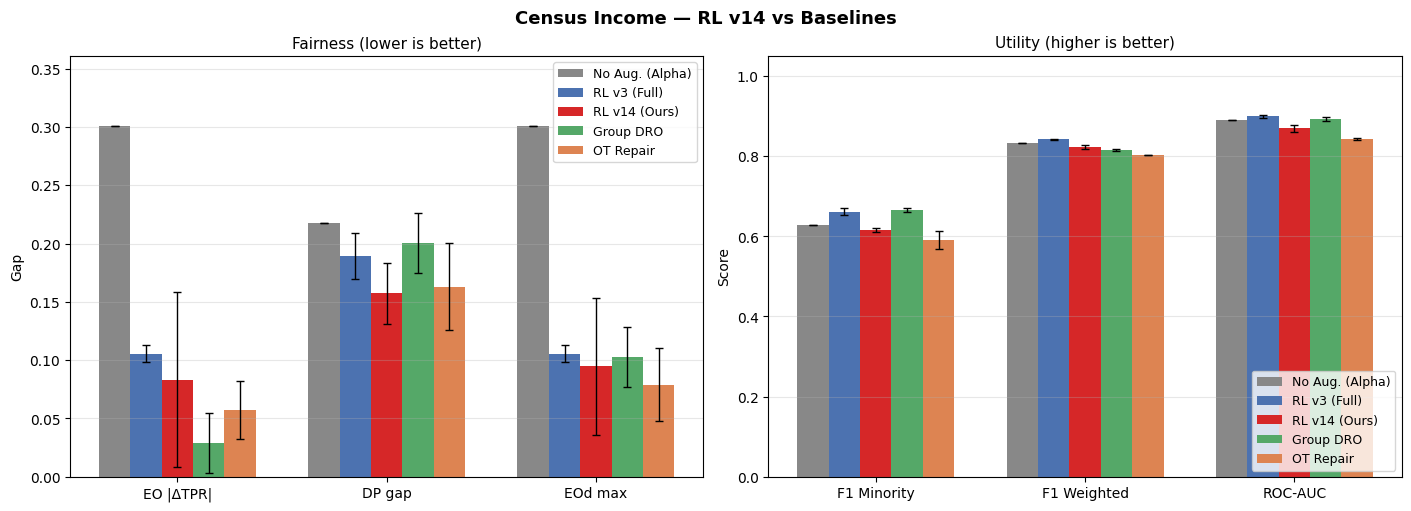

,EO,DP,F1 Min,F1 Weighted,ROC-AUC
Method,,,,,
No Aug. (Alpha),0.3007,0.2174,0.6272,0.8325,0.8899
RL v3 (Full),0.1057 ± 0.0071,0.1891 ± 0.0199,0.6609 ± 0.0089,0.8418 ± 0.0018,0.8998 ± 0.0038
RL v14 (Ours),0.0834 ± 0.0752,0.1573 ± 0.0263,0.6147 ± 0.0051,0.8232 ± 0.0046,0.8694 ± 0.0096
Group DRO,0.0290 ± 0.0259,0.2006 ± 0.0257,0.6666 ± 0.0050,0.8154 ± 0.0027,0.8923 ± 0.0049
OT Repair,0.0570 ± 0.0250,0.1630 ± 0.0374,0.5916 ± 0.0229,0.8032 ± 0.0010,0.8425 ± 0.0019


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from pathlib import Path
from IPython.display import display

ROOT = Path("training_runs")
UTIL_TOL = 0.005  # 0.5pp threshold for utility-preserved

# ============================================================
# METHODS — auto-discovers latest runs by prefix
# ============================================================

def _latest(pattern):
    candidates = sorted(ROOT.glob(pattern), key=lambda p: p.name)
    return candidates[-1].name if candidates else None

V3_FULL = "SPECv3_census_ablation_global_full_EP6000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202603092248_2f9e695b"
V14     = _latest("SPECv14_census_dvrl_twophase_3seeds_*")
GDRO    = _latest("BASELINE_group_dro_v14_baseline_gdro_census_*")
OTREP   = _latest("BASELINE_gaussian_ot_repair_v14_baseline_otrep_census_*")

METHODS = {
    "RL v3 (Full)":  V3_FULL,
    "RL v14 (Ours)": V14,
    "Group DRO":     GDRO,
    "OT Repair":     OTREP,
}

COLORS = {
    "No Aug. (Alpha)": "#888888",
    "RL v3 (Full)":    "#4C72B0",
    "RL v14 (Ours)":   "#d62728",
    "Group DRO":       "#55A868",
    "OT Repair":       "#DD8452",
}

# ============================================================
# Helpers
# ============================================================

def load_stats(folder):
    path = ROOT / folder / "final_test_metrics.csv"
    df = pd.read_csv(path)
    return df.mean(numeric_only=True), df.std(numeric_only=True)

def _get(series, key):
    if series is None: return float("nan")
    v = series.get(key, float("nan"))
    return float(v) if (v == v) else float("nan")

def fmt(mean, std):
    if mean != mean: return "—"
    if std is None or std != std: return f"{mean:.4f}"
    return f"{mean:.4f} ± {std:.4f}"

# ============================================================
# Load
# ============================================================
loaded = {}
for label, folder in METHODS.items():
    if folder is None:
        print(f"[warn] {label}: no run folder found — skipping")
        continue
    try:
        m, s = load_stats(folder)
        loaded[label] = (m, s)
    except Exception as e:
        print(f"[warn] {label} ({folder}): {e}")

# Alpha reference from v14
if V14 and "RL v14 (Ours)" in loaded:
    alpha_mean = loaded["RL v14 (Ours)"][0]
elif loaded:
    alpha_mean = next(iter(loaded.values()))[0]
else:
    alpha_mean = None

all_methods = {"No Aug. (Alpha)": (alpha_mean, None), **loaded}

# ============================================================
# BAR CHARTS
# ============================================================

FAIRNESS_METRICS = [
    ("eo_tpr_diff",  "EO |ΔTPR|"),
    ("dp_diff",      "DP gap"),
    ("eod_max_diff", "EOd max"),
]
UTILITY_METRICS = [
    ("f1_minority", "F1 Minority"),
    ("f1_weighted", "F1 Weighted"),
    ("roc_auc",     "ROC-AUC"),
]

labels = list(all_methods.keys())
n = len(labels)
colors_list = [COLORS.get(l, "#333333") for l in labels]

fig, (ax_f, ax_u) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
fig.suptitle("Census Income — RL v14 vs Baselines", fontsize=13, fontweight="bold")

x = np.arange(len(FAIRNESS_METRICS))
bar_w = 0.75 / max(n, 1)
offsets = (np.arange(n) - (n - 1) / 2.0) * bar_w

for i, (lbl, (m, s)) in enumerate(all_methods.items()):
    px = "alpha" if lbl == "No Aug. (Alpha)" else "beta"
    vals = np.array([_get(m, f"{px}_{col}") for col, _ in FAIRNESS_METRICS])
    errs = np.array([_get(s, f"{px}_{col}") for col, _ in FAIRNESS_METRICS]) if s is not None else np.zeros_like(vals)
    errs = np.where(errs != errs, 0.0, errs)
    ax_f.bar(x + offsets[i], vals, bar_w, color=colors_list[i], label=lbl,
             yerr=errs, capsize=3, error_kw={"elinewidth": 1.0})

ax_f.set_title("Fairness (lower is better)", fontsize=11)
ax_f.set_xticks(x); ax_f.set_xticklabels([l for _, l in FAIRNESS_METRICS])
ax_f.set_ylabel("Gap"); ax_f.grid(True, axis="y", alpha=0.3)
all_f = [_get(m, f"{'alpha' if l=='No Aug. (Alpha)' else 'beta'}_{col}")
         for l, (m, _) in all_methods.items() for col, _ in FAIRNESS_METRICS]
ax_f.set_ylim(0, max(0.05, max((v for v in all_f if v == v), default=0.05) * 1.2))
ax_f.legend(fontsize=9)

x_u = np.arange(len(UTILITY_METRICS))
for i, (lbl, (m, s)) in enumerate(all_methods.items()):
    px = "alpha" if lbl == "No Aug. (Alpha)" else "beta"
    vals = np.array([_get(m, f"{px}_{col}") for col, _ in UTILITY_METRICS])
    errs = np.array([_get(s, f"{px}_{col}") for col, _ in UTILITY_METRICS]) if s is not None else np.zeros_like(vals)
    errs = np.where(errs != errs, 0.0, errs)
    ax_u.bar(x_u + offsets[i], vals, bar_w, color=colors_list[i], label=lbl,
             yerr=errs, capsize=3, error_kw={"elinewidth": 1.0})

ax_u.set_title("Utility (higher is better)", fontsize=11)
ax_u.set_xticks(x_u); ax_u.set_xticklabels([l for _, l in UTILITY_METRICS])
ax_u.set_ylabel("Score"); ax_u.set_ylim(0, 1.05)
ax_u.grid(True, axis="y", alpha=0.3)
ax_u.legend(fontsize=9, loc="lower right")
plt.show()

# Summary table
ALL_COLS = [("eo_tpr_diff","EO"), ("dp_diff","DP"), ("f1_minority","F1 Min"),
            ("f1_weighted","F1 Weighted"), ("roc_auc","ROC-AUC")]
rows = {}
for lbl, (m, s) in all_methods.items():
    px = "alpha" if lbl == "No Aug. (Alpha)" else "beta"
    rows[lbl] = [fmt(_get(m, f"{px}_{c}"), _get(s, f"{px}_{c}") if s is not None else float("nan"))
                 for c, _ in ALL_COLS]
table_df = pd.DataFrame(rows, index=[l for _, l in ALL_COLS]).T
table_df.index.name = "Method"
display(table_df)


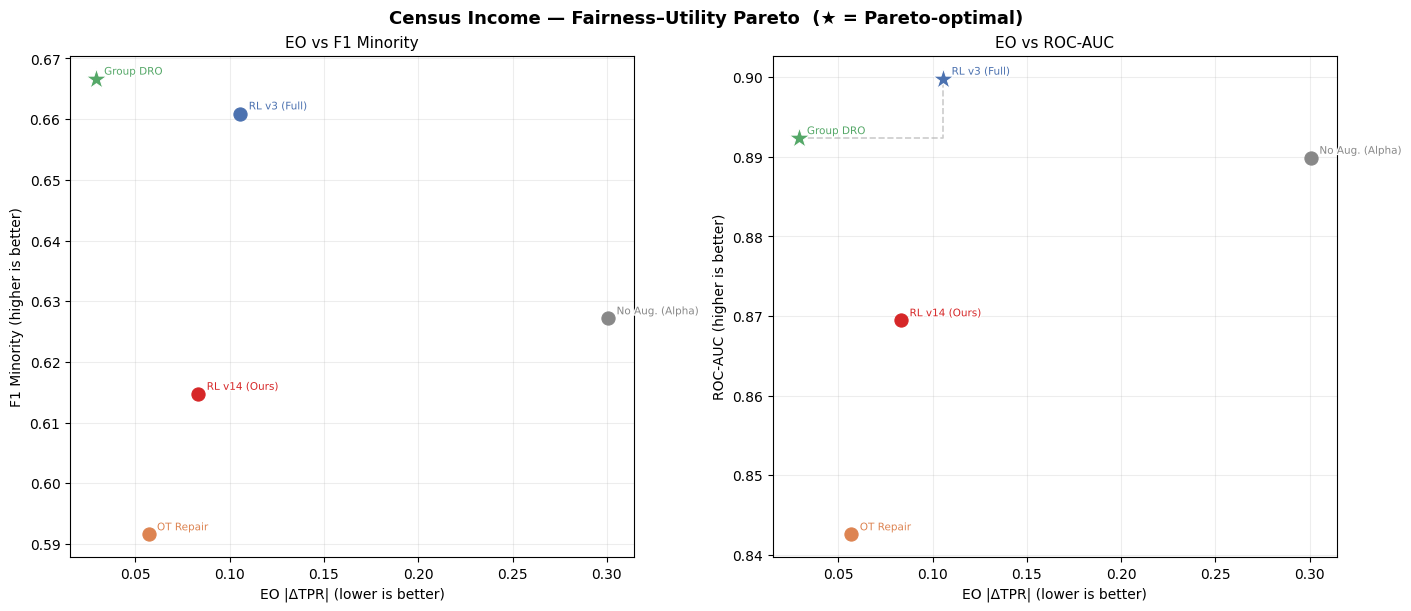

UAFI = harmonic mean(fairness_gain, utility_retention) | Win = EO improved AND all utility within -0.5pp


,EO,Delta_EO_%,Delta_F1m,Delta_F1w,Delta_AUC,UAFI,Util.Pres.,Win,Par.F1m,Par.AUC
Method,,,,,,,,,,
No Aug. (Alpha),0.3007,+0.00,+0.00,+0.00,+0.00,0.000,v,,,
RL v3 (Full),0.1057,+64.86,+3.38,+0.93,+0.99,0.787,v,v,,*
RL v14 (Ours),0.0834,+72.27,-1.24,-0.93,-2.04,0.833,,,,
Group DRO,0.0290,+90.37,+3.95,-1.72,+0.25,0.940,,,*,*
OT Repair,0.0570,+81.04,-3.56,-2.94,-4.73,0.877,,,,


In [29]:
# ============================================================
# FAIRNESS-UTILITY PARETO SCATTER + TRADEOFF TABLE
# ============================================================

def uafi_multi(eo, eo_a, f1w, f1w_a, auc, auc_a, acc, acc_a):
    fg = max(0.0, (eo_a - eo) / (eo_a + 1e-9))
    retentions = []
    for v, va in [(f1w, f1w_a), (auc, auc_a), (acc, acc_a)]:
        if not (v != v or va != va or va < 1e-9):
            retentions.append(min(1.0, v / va))
    if not retentions: return float("nan")
    ur = float(sum(retentions)) / len(retentions)
    if fg + ur < 1e-9: return 0.0
    return 2.0 * fg * ur / (fg + ur)

def pareto_mask(x_vals, y_vals):
    n = len(x_vals)
    dominated = [False] * n
    for i in range(n):
        for j in range(n):
            if i == j: continue
            if x_vals[j] <= x_vals[i] and y_vals[j] >= y_vals[i]:
                if x_vals[j] < x_vals[i] or y_vals[j] > y_vals[i]:
                    dominated[i] = True; break
    return [not d for d in dominated]

eo_a  = _get(alpha_mean, "alpha_eo_tpr_diff")
f1w_a = _get(alpha_mean, "alpha_f1_weighted")
auc_a = _get(alpha_mean, "alpha_roc_auc")
acc_a = _get(alpha_mean, "alpha_acc")
f1m_a = _get(alpha_mean, "alpha_f1_minority")

plot_data = {}
for label, (m, s) in all_methods.items():
    px = "alpha" if label == "No Aug. (Alpha)" else "beta"
    eo  = _get(m, f"{px}_eo_tpr_diff")
    f1m = _get(m, f"{px}_f1_minority")
    f1w = _get(m, f"{px}_f1_weighted")
    auc = _get(m, f"{px}_roc_auc")
    acc = _get(m, f"{px}_acc")
    if eo == eo:  # not nan
        plot_data[label] = {
            "eo": eo, "f1m": f1m, "f1w": f1w, "auc": auc, "acc": acc,
            "std_eo":  _get(s, f"{px}_eo_tpr_diff") if s is not None else float("nan"),
            "std_f1m": _get(s, f"{px}_f1_minority")  if s is not None else float("nan"),
            "std_auc": _get(s, f"{px}_roc_auc")      if s is not None else float("nan"),
        }

labels_p = list(plot_data.keys())
eo_arr  = [plot_data[l]["eo"]  for l in labels_p]
f1m_arr = [plot_data[l]["f1m"] for l in labels_p]
auc_arr = [plot_data[l]["auc"] for l in labels_p]

pf_f1m = pareto_mask(eo_arr, f1m_arr)
pf_auc = pareto_mask(eo_arr, auc_arr)

def _scatter_panel(ax, y_key, ylabel, title, pf):
    for i, label in enumerate(labels_p):
        d = plot_data[label]
        x, y = d["eo"], d[y_key]
        if x != x or y != y: continue
        color  = COLORS.get(label, "#333333")
        marker = "*" if pf[i] else "o"
        ms     = 250 if pf[i] else 90
        ax.scatter(x, y, c=color, s=ms, marker=marker, zorder=3,
                   edgecolors="white" if pf[i] else color, linewidths=0.8)
        ax.annotate(label, (x, y), fontsize=7.5, color=color,
                    xytext=(6, 3), textcoords="offset points",
                    path_effects=[pe.withStroke(linewidth=2, foreground="white")])
    pts = sorted([(eo_arr[i], plot_data[labels_p[i]][y_key])
                  for i in range(len(labels_p))
                  if pf[i] and eo_arr[i]==eo_arr[i] and plot_data[labels_p[i]][y_key]==plot_data[labels_p[i]][y_key]],
                 key=lambda t: t[0])
    if len(pts) >= 2:
        px2, py = zip(*pts)
        ax.step(px2, py, where="post", color="#aaaaaa", lw=1.2, ls="--", alpha=0.6, zorder=1)
    ax.set_xlabel("EO |ΔTPR| (lower is better)", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11); ax.grid(True, alpha=0.22)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
fig.suptitle("Census Income — Fairness–Utility Pareto  (★ = Pareto-optimal)", fontsize=13, fontweight="bold")
_scatter_panel(ax1, "f1m", "F1 Minority (higher is better)", "EO vs F1 Minority", pf_f1m)
_scatter_panel(ax2, "auc", "ROC-AUC (higher is better)",     "EO vs ROC-AUC",     pf_auc)
plt.show()

# Tradeoff table
rows = []
for label, d in plot_data.items():
    eo  = d["eo"];  f1m = d["f1m"]; f1w = d["f1w"]; auc = d["auc"]; acc = d["acc"]
    def pct(v, va): return (va - v)/(va+1e-9)*100 if (v==v and va==va) else float("nan")
    def pp(v, va):  return (v - va)*100            if (v==v and va==va) else float("nan")
    def fmtd(v):    return ("+" if v>=0 else "")+f"{v:.2f}" if v==v else "—"
    d_eo=pct(eo,eo_a); d_f1m=pp(f1m,f1m_a); d_f1w=pp(f1w,f1w_a); d_auc=pp(auc,auc_a); d_acc=pp(acc,acc_a)
    score = uafi_multi(eo, eo_a, f1w, f1w_a, auc, auc_a, acc, acc_a)
    util_ok = all(x==x and x >= -UTIL_TOL*100 for x in [d_f1w, d_auc, d_acc])
    win = (d_eo==d_eo and d_eo > 0) and util_ok
    idx = labels_p.index(label)
    rows.append({
        "Method":      label,
        "EO":          f"{eo:.4f}" if eo==eo else "—",
        "Delta_EO_%":  fmtd(d_eo),
        "Delta_F1m":   fmtd(d_f1m),
        "Delta_F1w":   fmtd(d_f1w),
        "Delta_AUC":   fmtd(d_auc),
        "UAFI":        f"{score:.3f}" if score==score else "—",
        "Util.Pres.":  "v" if util_ok else "",
        "Win":         "v" if win     else "",
        "Par.F1m":     "*" if pf_f1m[idx] else "",
        "Par.AUC":     "*" if pf_auc[idx]  else "",
    })

def highlight(row):
    if row.get("Win") == "v": return ["background-color: #d4edda"]*len(row)
    if row.get("Util.Pres.") == "v": return ["background-color: #fff3cd"]*len(row)
    return [""]*len(row)

tbl = pd.DataFrame(rows).set_index("Method")
print(f"UAFI = harmonic mean(fairness_gain, utility_retention) | Win = EO improved AND all utility within -{UTIL_TOL*100:.1f}pp")
display(tbl.style.apply(highlight, axis=1))


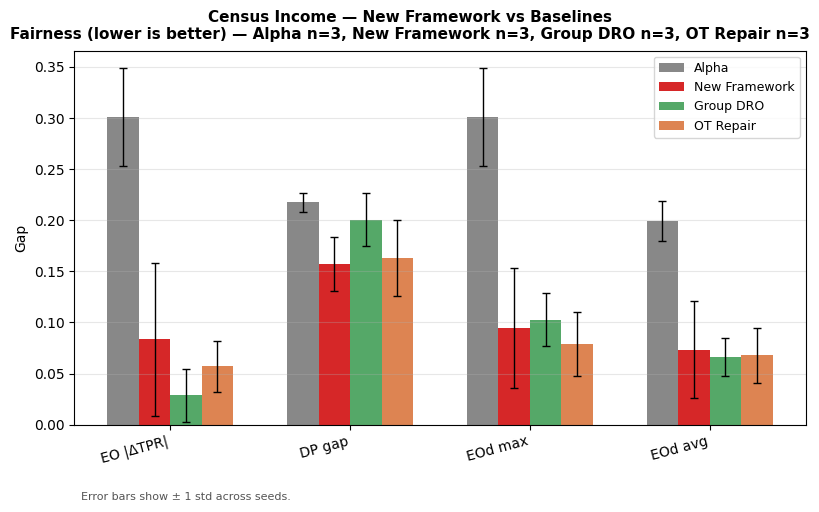

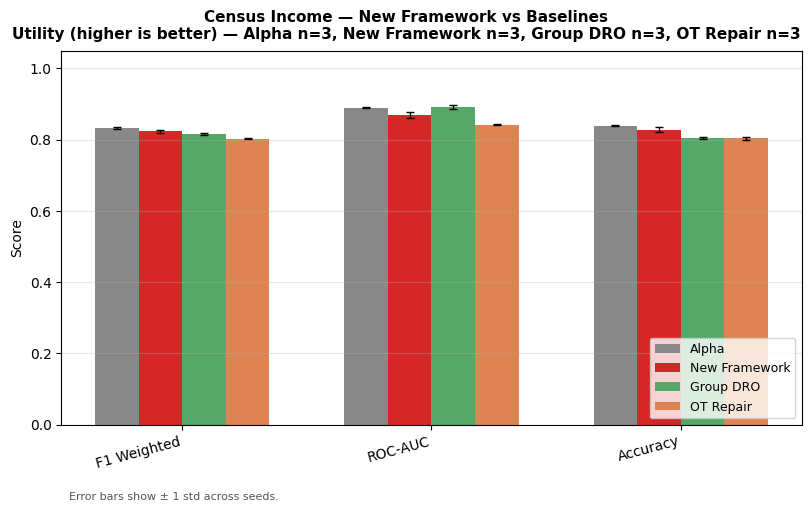

,EO |ΔTPR|,DP gap,EOd max,EOd avg,F1 Weighted,ROC-AUC,Accuracy
Method,,,,,,,
Alpha,0.3007 ± 0.0478,0.2174 ± 0.0090,0.3007 ± 0.0478,0.1992 ± 0.0200,0.8325 ± 0.0026,0.8899 ± 0.0021,0.8394 ± 0.0015
New Framework,0.0834 ± 0.0752,0.1573 ± 0.0263,0.0947 ± 0.0586,0.0735 ± 0.0479,0.8232 ± 0.0046,0.8694 ± 0.0096,0.8281 ± 0.0077
Group DRO,0.0290 ± 0.0259,0.2006 ± 0.0257,0.1028 ± 0.0259,0.0659 ± 0.0186,0.8154 ± 0.0027,0.8923 ± 0.0049,0.8054 ± 0.0032
OT Repair,0.0570 ± 0.0250,0.1630 ± 0.0374,0.0791 ± 0.0310,0.0678 ± 0.0266,0.8032 ± 0.0010,0.8425 ± 0.0019,0.8034 ± 0.0045


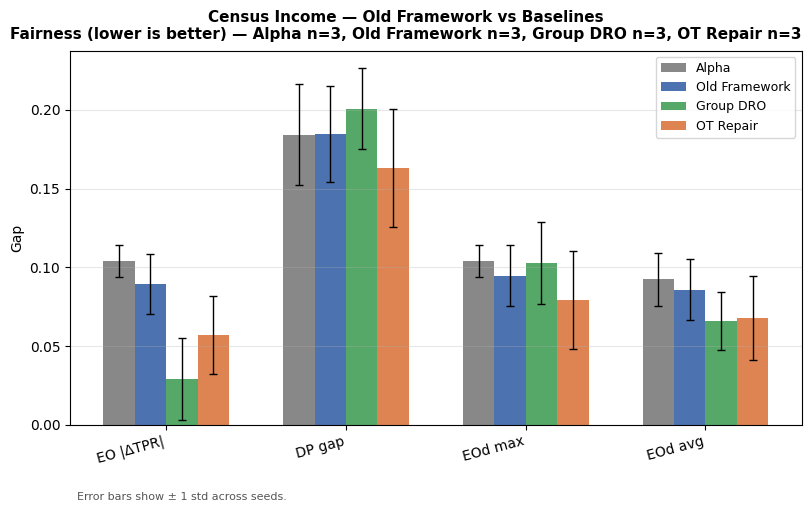

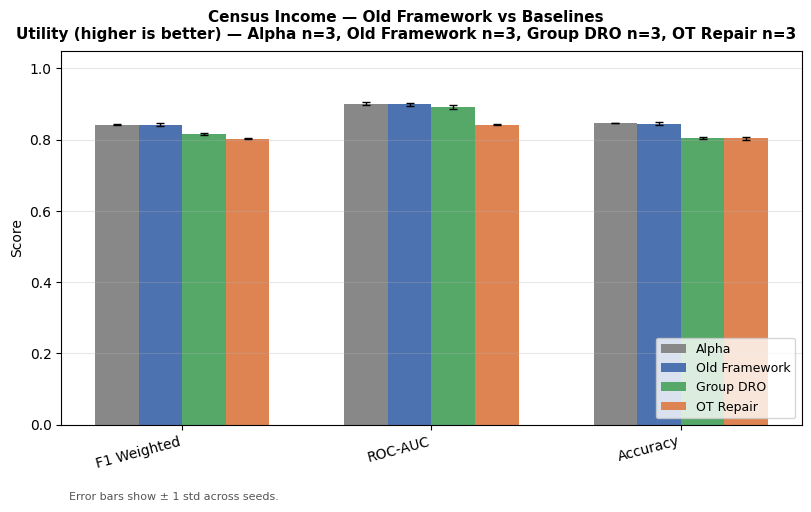

,EO |ΔTPR|,DP gap,EOd max,EOd avg,F1 Weighted,ROC-AUC,Accuracy
Method,,,,,,,
Alpha,0.1039 ± 0.0100,0.1842 ± 0.0320,0.1039 ± 0.0100,0.0924 ± 0.0168,0.8425 ± 0.0026,0.9013 ± 0.0034,0.8467 ± 0.0010
Old Framework,0.0891 ± 0.0190,0.1848 ± 0.0303,0.0946 ± 0.0194,0.0858 ± 0.0193,0.8423 ± 0.0041,0.8996 ± 0.0036,0.8453 ± 0.0050
Group DRO,0.0290 ± 0.0259,0.2006 ± 0.0257,0.1028 ± 0.0259,0.0659 ± 0.0186,0.8154 ± 0.0027,0.8923 ± 0.0049,0.8054 ± 0.0032
OT Repair,0.0570 ± 0.0250,0.1630 ± 0.0374,0.0791 ± 0.0310,0.0678 ± 0.0266,0.8032 ± 0.0010,0.8425 ± 0.0019,0.8034 ± 0.0045


In [31]:

# ============================================================
# TWO SEPARATE COMPARISON GRAPHS
#   Graph 1: New Framework (v14) vs baselines  (Alpha = v14 alpha)
#   Graph 2: Old Framework (v3)  vs baselines  (Alpha = v3  alpha)
#
# Fairness and utility are separate figures per graph.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path("training_runs")

def _latest(pattern):
    candidates = sorted(ROOT.glob(pattern), key=lambda p: p.name)
    return candidates[-1].name if candidates else None

FOLDERS = {
    "v14":   _latest("SPECv14_census_dvrl_twophase_3seeds_*"),
    "v3":    "SPECv3_census_ablation_global_anchors_EP6000_PCA10_REWfairness_minID1_majID0_TRJ2000_REAL3000_GG202603121842_acafe162",
    "gdro":  _latest("BASELINE_group_dro_v14_baseline_gdro_census_*"),
    "otrep": _latest("BASELINE_gaussian_ot_repair_v14_baseline_otrep_census_*"),
}

def load_stats(key):
    folder = FOLDERS[key]
    if folder is None:
        return None, None, 0
    path = ROOT / folder / "final_test_metrics.csv"
    df = pd.read_csv(path)
    return df.mean(numeric_only=True), df.std(numeric_only=True), len(df)

stats = {k: load_stats(k) for k in FOLDERS}  # mean, std, n_seeds

FAIRNESS = [
    ("eo_tpr_diff",  "EO |ΔTPR|"),
    ("dp_diff",      "DP gap"),
    ("eod_max_diff", "EOd max"),
    ("eod_avg_diff", "EOd avg"),
]
UTILITY = [
    ("f1_weighted", "F1 Weighted"),
    ("roc_auc",     "ROC-AUC"),
    ("acc",         "Accuracy"),
]

ERRBAR_NOTE = "Error bars show ± 1 std across seeds."

def get(mean, std, prefix, metric):
    m = float(mean.get(f"{prefix}_{metric}", np.nan)) if mean is not None else np.nan
    s = float(std.get(f"{prefix}_{metric}",  np.nan)) if std  is not None else np.nan
    return m, s

def plot_comparison(base_title, ref_key, method_keys, method_labels, colors):
    ref_mean, ref_std, ref_n = stats[ref_key]

    # Collect seed counts for title
    seed_counts = {"Alpha": ref_n}
    for k, lbl in zip(method_keys, method_labels):
        seed_counts[lbl] = stats[k][2]
    seed_str = ", ".join(f"{lbl} n={n}" for lbl, n in seed_counts.items())

    labels  = ["Alpha"] + method_labels
    n       = len(labels)
    bar_w   = 0.70 / n
    offsets = (np.arange(n) - (n - 1) / 2.0) * bar_w

    def get_vals_errs(lbl, metrics):
        if lbl == "Alpha":
            mean, std, _ = ref_mean, ref_std, ref_n
            prefix = "alpha"
        else:
            mean, std, _ = stats[method_keys[labels.index(lbl) - 1]]
            prefix = "beta"
        vals = np.array([get(mean, std, prefix, m)[0] for m, _ in metrics])
        errs = np.array([get(mean, std, prefix, m)[1] for m, _ in metrics])
        errs = np.where(np.isnan(errs), 0.0, errs)
        return vals, errs

    # ── Fairness figure ──────────────────────────────────────
    fig_f, ax_f = plt.subplots(figsize=(8, 5), constrained_layout=True)
    fig_f.suptitle(
        f"{base_title}\nFairness (lower is better) — {seed_str}",
        fontsize=11, fontweight="bold"
    )
    x_f = np.arange(len(FAIRNESS))
    for i, (lbl, color) in enumerate(zip(labels, colors)):
        vals, errs = get_vals_errs(lbl, FAIRNESS)
        ax_f.bar(x_f + offsets[i], vals, bar_w, label=lbl, color=color,
                 yerr=errs, capsize=3, error_kw={"elinewidth": 1.0})
    ax_f.set_xticks(x_f)
    ax_f.set_xticklabels([l for _, l in FAIRNESS], rotation=15, ha="right")
    ax_f.set_ylabel("Gap")
    ax_f.set_ylim(0, None)
    ax_f.grid(True, axis="y", alpha=0.3)
    ax_f.legend(fontsize=9)
    ax_f.text(0.01, -0.18, ERRBAR_NOTE, transform=ax_f.transAxes,
              fontsize=8, color="#555555", va="top")
    plt.show()

    # ── Utility figure ───────────────────────────────────────
    fig_u, ax_u = plt.subplots(figsize=(8, 5), constrained_layout=True)
    fig_u.suptitle(
        f"{base_title}\nUtility (higher is better) — {seed_str}",
        fontsize=11, fontweight="bold"
    )
    x_u = np.arange(len(UTILITY))
    for i, (lbl, color) in enumerate(zip(labels, colors)):
        vals, errs = get_vals_errs(lbl, UTILITY)
        ax_u.bar(x_u + offsets[i], vals, bar_w, label=lbl, color=color,
                 yerr=errs, capsize=3, error_kw={"elinewidth": 1.0})
    ax_u.set_xticks(x_u)
    ax_u.set_xticklabels([l for _, l in UTILITY], rotation=15, ha="right")
    ax_u.set_ylabel("Score")
    ax_u.set_ylim(0, 1.05)
    ax_u.grid(True, axis="y", alpha=0.3)
    ax_u.legend(fontsize=9, loc="lower right")
    ax_u.text(0.01, -0.18, ERRBAR_NOTE, transform=ax_u.transAxes,
              fontsize=8, color="#555555", va="top")
    plt.show()

    # ── Summary table ─────────────────────────────────────────
    all_cols = FAIRNESS + UTILITY
    rows = {}
    for lbl in labels:
        if lbl == "Alpha":
            mean, std, _ = ref_mean, ref_std, ref_n; prefix = "alpha"
        else:
            mean, std, _ = stats[method_keys[labels.index(lbl) - 1]]; prefix = "beta"
        def fmt(m, s):
            if np.isnan(m): return "—"
            if np.isnan(s): return f"{m:.4f}"
            return f"{m:.4f} ± {s:.4f}"
        rows[lbl] = [fmt(*get(mean, std, prefix, c)) for c, _ in all_cols]
    tbl = pd.DataFrame(rows, index=[l for _, l in all_cols]).T
    tbl.index.name = "Method"
    display(tbl)

# ── Graph 1: New Framework (v14) vs baselines ────────────────
plot_comparison(
    base_title    = "Census Income — New Framework vs Baselines",
    ref_key       = "v14",
    method_keys   = ["v14",             "gdro",      "otrep"],
    method_labels = ["New Framework",   "Group DRO", "OT Repair"],
    colors        = ["#888888",         "#d62728",   "#55A868",   "#DD8452"],
)

# ── Graph 2: Old Framework (v3) vs baselines ─────────────────
plot_comparison(
    base_title    = "Census Income — Old Framework vs Baselines",
    ref_key       = "v3",
    method_keys   = ["v3",              "gdro",      "otrep"],
    method_labels = ["Old Framework",   "Group DRO", "OT Repair"],
    colors        = ["#888888",         "#4C72B0",   "#55A868",   "#DD8452"],
)


In [ ]:
# =============================================================================
# MAIN RESULTS TABLE — Multi-Dataset Comparison
# Run this cell to regenerate the paper results table.
# Add new run directories to the RUNS dict as they complete.
# =============================================================================

import csv, statistics
import pandas as pd
from pathlib import Path

ROOT = Path('training_runs')

def load(folder):
    if folder is None:
        return None
    p = ROOT / folder / 'final_test_metrics.csv'
    if not p.exists():
        return None
    rows = list(csv.DictReader(open(p)))
    if not rows:
        return None
    # De-duplicate by seed (merged runs can have repeated seeds)
    seen, unique = set(), []
    for r in rows:
        key = r.get('seed', '')
        if key not in seen:
            seen.add(key); unique.append(r)
    rows = unique
    means, stds = {}, {}
    for col in rows[0].keys():
        try:
            vals = [float(r[col]) for r in rows]
            means[col] = statistics.mean(vals)
            stds[col]  = statistics.stdev(vals) if len(vals) > 1 else 0.0
        except (ValueError, TypeError):
            pass
    return means, stds, len(rows)

def _latest(pattern):
    candidates = sorted(ROOT.glob(pattern), key=lambda p: p.name)
    return candidates[-1].name if candidates else None

def _fmt(means, stds, n, col, prefix='beta'):
    if means is None: return 'TBD'
    key = f'{prefix}_{col}'
    v = means.get(key)
    s = stds.get(key)
    if v is None: return '?'
    seed_note = f'({n}s)'
    if s is not None and s > 0:
        return f'{v:.3f}\u00b1{s:.3f} {seed_note}'
    return f'{v:.3f} {seed_note}'

def _alpha(means, col):
    if means is None: return '—'
    v = means.get(f'alpha_{col}')
    return f'{v:.3f}' if v is not None else '—'

# ============================================================
# RUN DIRECTORIES  — update these as new results arrive
# ============================================================

RUNS = {
    # ---- Census Income ----
    'census_010_ours':        _latest('SPECv18_ablation_global_only_bias010_census_*'),
    'census_005_ours':        _latest('SPECv17a_bias05_rl_census_5seeds_*'),
    'census_010_gdro':        None,   # pending DRAC
    'census_005_gdro':        None,   # pending DRAC
    'census_010_otrep':       None,   # pending DRAC
    'census_005_otrep':       None,   # pending DRAC
    'census_010_ctgan':       None,   # pending DRAC
    'census_005_ctgan':       None,   # pending DRAC
    'census_010_flb':         _latest('BASELINE_fairness_loss_balancing_v18_bias010_flb_census_*'),
    'census_005_flb':         _latest('BASELINE_fairness_loss_balancing_v18_bias005_flb_census_*'),
    'census_010_fairtabddpm': _latest('BASELINE_fairtabddpm_v18_bias010_fairtabddpm_census_*'),
    'census_005_fairtabddpm': _latest('BASELINE_fairtabddpm_v18_bias005_fairtabddpm_census_*'),
    # ---- Credit Card ----
    'credit_010_ours':        None,   # pending DRAC (v18)
    'credit_005_ours':        None,   # pending DRAC (v18)
    'credit_010_gdro':        None,   # pending DRAC
    'credit_005_gdro':        None,   # pending DRAC
    'credit_010_otrep':       None,   # pending DRAC
    'credit_005_otrep':       None,   # pending DRAC
    'credit_010_ctgan':       None,   # pending DRAC
    'credit_005_ctgan':       None,   # pending DRAC
    'credit_010_flb':         _latest('BASELINE_fairness_loss_balancing_v18_bias010_flb_credit_*'),
    'credit_005_flb':         _latest('BASELINE_fairness_loss_balancing_v18_bias005_flb_credit_*'),
    'credit_010_fairtabddpm': _latest('BASELINE_fairtabddpm_v18_bias010_fairtabddpm_credit_*'),
    'credit_005_fairtabddpm': _latest('BASELINE_fairtabddpm_v18_bias005_fairtabddpm_credit_*'),
    # ---- CAPTURE-24 ----
    'c24_002_ours':           _latest('SPECp1_capture24_v18_k3_3s_*'),
    'c24_002_gdro':           _latest('BASELINE_group_dro_p1_capture24_bias002_gdro_*'),
    'c24_002_otrep':          _latest('BASELINE_gaussian_ot_repair_p1_capture24_bias002_otrep_*'),
    'c24_002_ctgan':          _latest('BASELINE_ctgan_p1_capture24_bias002_ctgan_*'),
    'c24_002_flb':            _latest('BASELINE_fairness_loss_balancing_p1_capture24_bias002_flb_*'),
    'c24_002_fairtabddpm':    _latest('BASELINE_fairtabddpm_p1_capture24_bias002_fairtabddpm_*'),
}

loaded = {k: load(v) for k, v in RUNS.items()}

# ============================================================
# TABLE BUILDER
# ============================================================

METHOD_KEYS = [
    ('No Aug. (\u03b1)',     None,               'alpha'),
    ('GroupDRO',             '{ds}_gdro',         'beta'),
    ('OT Repair',            '{ds}_otrep',        'beta'),
    ('CTGAN',                '{ds}_ctgan',        'beta'),
    ('Kim et al. (FLB)',     '{ds}_flb',          'beta'),
    ('FairTabDDPM',          '{ds}_fairtabddpm',  'beta'),
    ('Ours (v18)',            '{ds}_ours',         'beta'),
]

def make_table(title, ds_prefix, alpha_source_key):
    alpha_data = loaded.get(alpha_source_key)
    alpha_means = alpha_data[0] if alpha_data else None
    rows = []
    for method, key_tmpl, prefix in METHOD_KEYS:
        if prefix == 'alpha':
            row = {
                'Method': method,
                'EO\u2193':  _alpha(alpha_means, 'eo_tpr_diff'),
                'F1w\u2191': _alpha(alpha_means, 'f1_weighted'),
                'AUC\u2191': _alpha(alpha_means, 'roc_auc'),
            }
        else:
            key = key_tmpl.format(ds=ds_prefix)
            d = loaded.get(key)
            if d is None:
                row = {'Method': method, 'EO\u2193': 'TBD', 'F1w\u2191': 'TBD', 'AUC\u2191': 'TBD'}
            else:
                means, stds, n = d
                row = {
                    'Method': method,
                    'EO\u2193':  _fmt(means, stds, n, 'eo_tpr_diff'),
                    'F1w\u2191': _fmt(means, stds, n, 'f1_weighted'),
                    'AUC\u2191': _fmt(means, stds, n, 'roc_auc'),
                }
        rows.append(row)
    df = pd.DataFrame(rows).set_index('Method')
    print(f'\n{"="*68}')
    print(f'  {title}')
    print(f'{"="*68}')
    print(df.to_string())

make_table('Census Income  |  bias_pct=0.10  (43 min-pos training examples)',
           'census_010', alpha_source_key='census_010_ours')
make_table('Census Income  |  bias_pct=0.05  (17 min-pos training examples)',
           'census_005', alpha_source_key='census_005_ours')
make_table('Credit Card  |  bias_pct=0.10',
           'credit_010', alpha_source_key='credit_010_flb')
make_table('Credit Card  |  bias_pct=0.05',
           'credit_005', alpha_source_key='credit_005_flb')
make_table('CAPTURE-24  |  bias_pct=0.02  (~60 female MVPA training examples)',
           'c24_002', alpha_source_key='c24_002_ours')
